<img src="https://media-exp1.licdn.com/dms/image/C4E1BAQEMI2VQQ5_Utw/company-background_10000/0/1583983402116?e=2159024400&v=beta&t=Yhx0JDUeUOAT-GVzNFn-CsJLu63KdxKQqGBkjGybOsM">


# Introduccion

La tarea principal de la agrupación en clústeres es descubrir grupos "naturales" dentro de un conjunto de datos no etiquetado, lo que significa que es una tarea de ML no supervisada. Y es importante, ya que se utiliza en muchos dominios científicos, de ingeniería y empresariales. Una de las aplicaciones más conocidas del clustering son:

1. Segmentación de clientes (para un marketing eficiente)
2. Segmentación de imágenes
3. Agrupación de documentos.

Hay muchos algoritmos de clustering que se pueden dividir en dos tipos principales: jerárquicos y particionales.

*	Los algoritmos jerárquicos dividen recursivamente un conjunto de datos en un subconjunto más pequeño hasta que un subconjunto contiene solo un elemento. Esto se puede representar con un dendrograma que se parece a un árbol. Se puede construir desde las hojas hasta el roo (enfoque aglomerador) o desde la raíz hasta las hojas (enfoque divisivo). En la agrupación jerárquica, no es necesario especificar el número de clústeres, pero sí definir una condición de terminación para la división/proceso.

*	Los algoritmos particionales dividen un conjunto de datos en varios subconjuntos (clústeres) en función de un criterio determinado. Para algunos algoritmos, el número de clústeres debe definirse a priori (por ejemplo, K-Means) y para otros no (DBSCAN). Definir el número de clústeres antes de ejecutar un algoritmo a menudo requiere un conocimiento específico del dominio que a menudo es desafiante (o incluso imposible) en muchas aplicaciones. Esto llevó al desarrollo de muchas heurísticas y enfoques simplificados que ayudan al analista sin conocimiento de dominio a elegir el número apropiado de clústeres.

Hay una gran cantidad de algoritmos de clustering y actualmente, no hay uno solo que domine a otros. La elección de la mejor depende de la base de datos en sí, un dominio de aplicación y los requisitos y expectativas del cliente. Este portátil se centra en cuatro algoritmos particionales: K-Means, DBSCAN, Affinity Propagation y Spectral Clustering. Todos están implementados en una conocida biblioteca de Python: Scikit-Learn.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

In [ ]:
mall_data = pd.read_csv('/content/drive/MyDrive/Curso Estadistica con Python/Mall_Customers.csv')
print('La cantidad de filas son {} y la cantidad de columnas son {}'.format(mall_data.shape[0], mall_data.shape[1]))

La cantidad de filas son 200 y la cantidad de columnas son 5


In [ ]:
mall_data.sample(10)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
49,50,Female,31,40,42
46,47,Female,50,40,55
98,99,Male,48,61,42
82,83,Male,67,54,41
165,166,Female,36,85,75
12,13,Female,58,20,15
55,56,Male,47,43,41
44,45,Female,49,39,28
79,80,Female,49,54,42
112,113,Female,38,64,42


In [ ]:
mall_data.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


Tenemos 5 columnas:

* CustomerID = Identificador unico del cliente
* Gender = Genero (Binaria)
* Age = Tipo numerica
* Annual Income = Ingreso Anual de tipo numeroca
* Spending Score = Puntuacion del Gasto (1-100)

In [ ]:
mall_data.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


## Analisis Exploratorio de Datos

El EDA contiene una investigacion estadistica basica de una base determinada. Es un punto crucial en cualquier analisis, ya que nos permite una mejor comprension de los datos que estaremos utilizando. Por lo general se subdivide en 2 parte: Distribuciones y Correlaciones.

### Distribuciones

Debemos de revisar las distribuciones de las variables numericas, y lo representaremos por las diferentes variables.

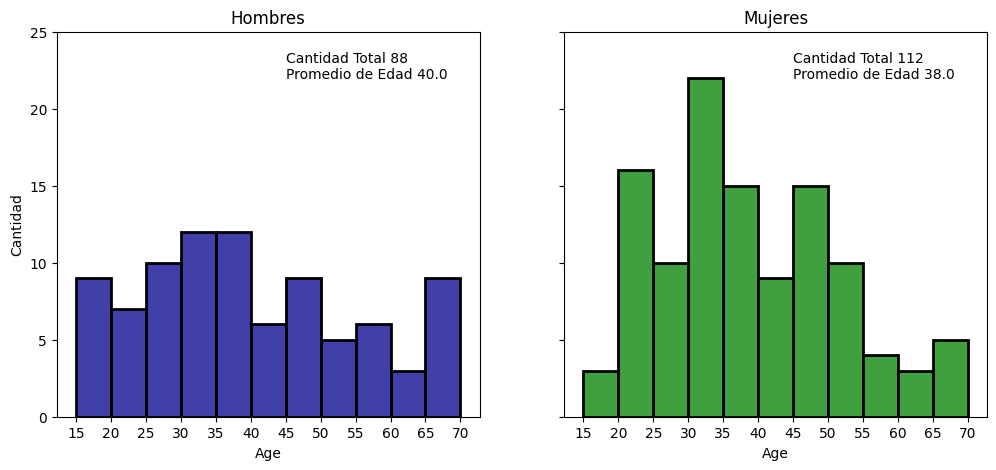

In [ ]:
# Separar los datos por género
hombres_edad = mall_data[mall_data['Gender'] == 'Male']['Age']
mujeres_edad = mall_data[mall_data['Gender'] == 'Female']['Age']

# Definir los bins para las edades
edades_bins = range(15, 75, 5)

# Crear la figura y los ejes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Graficar el histograma para hombres
sns.histplot(hombres_edad, bins=edades_bins, color='darkblue', ax=ax1,
             edgecolor='k', linewidth=2)
ax1.set_xticks(edades_bins)
ax1.set_ylim(top=25)
ax1.set_ylabel('Cantidad')
ax1.set_title('Hombres')
ax1.text(45, 23, f"Cantidad Total {hombres_edad.count()}")
ax1.text(45, 22, f"Promedio de Edad {round(hombres_edad.mean(), 0)}")
ax1.grid(False)

# Graficar el histograma para mujeres
sns.histplot(mujeres_edad, bins=edades_bins, color='green', ax=ax2,
             edgecolor='k', linewidth=2)
ax2.set_xticks(edades_bins)
ax2.set_ylim(top=25)
ax2.set_ylabel('Cantidad')
ax2.set_title('Mujeres')
ax2.text(45, 23, f"Cantidad Total {mujeres_edad.count()}")
ax2.text(45, 22, f"Promedio de Edad {round(mujeres_edad.mean(), 0)}")
ax2.grid(False)

plt.show()

In [ ]:
print('P-value del Kolgomorov-Smirnov test {:.2f}'.format(stats.ks_2samp(hombres_edad,mujeres_edad)[1]))

P-value del Kolgomorov-Smirnov test 0.49


La edad promedio de los clientes masculinos es ligeremante mas alta que la de las mujeres (40 vrs 38). La distribucion de la edad masculina es mas uniforme que las de las mujeres, donde podemos observar que el grupo de edad mas grande es de 30 a 35.La prueba de Kolgomorov-Smirnov muestra que las diferencias entre esos 2 grupos (Hombres y Mujeres) son estadisticamente insignificantes

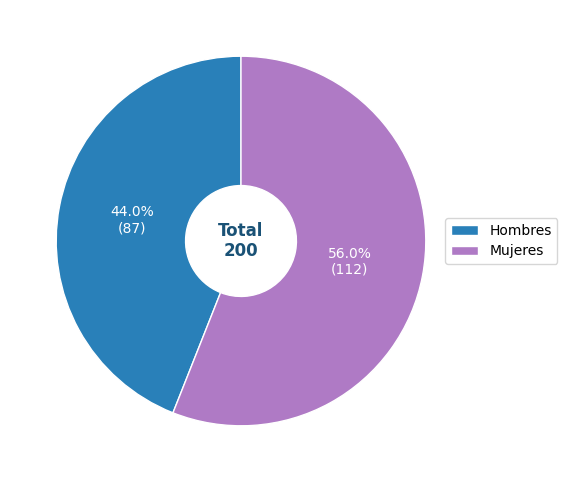

In [ ]:
def etiquetador(pct, allvals):
  absoluto = int(pct/100 * np.sum(allvals))
  return "{:.1f}%\n({:d})".format(pct,absoluto)

sizes = [hombres_edad.count(),mujeres_edad.count()]

fig0, ax1 = plt.subplots(figsize = (6,6))

proporciones, texts,autotexts = ax1.pie(sizes,
                                        autopct = lambda pct: etiquetador(pct,sizes),
                                        radius = 1,
                                        colors = ['#2980B9','#AF7AC5'],
                                        startangle = 90,
                                        textprops = dict(color = 'w'),
                                        wedgeprops = dict(width = 0.7, edgecolor = 'w'))

ax1.legend(proporciones, ['Hombres','Mujeres'],
           loc = 'center right',
           bbox_to_anchor = (0.7, 0 , 0.5, 1))

plt.text(0,0, 'Total\n{}'.format(mall_data['Age'].count()),
         weight = 'bold', size = 12, color = '#1A5276',
         ha = 'center',va = 'center')

plt.show()

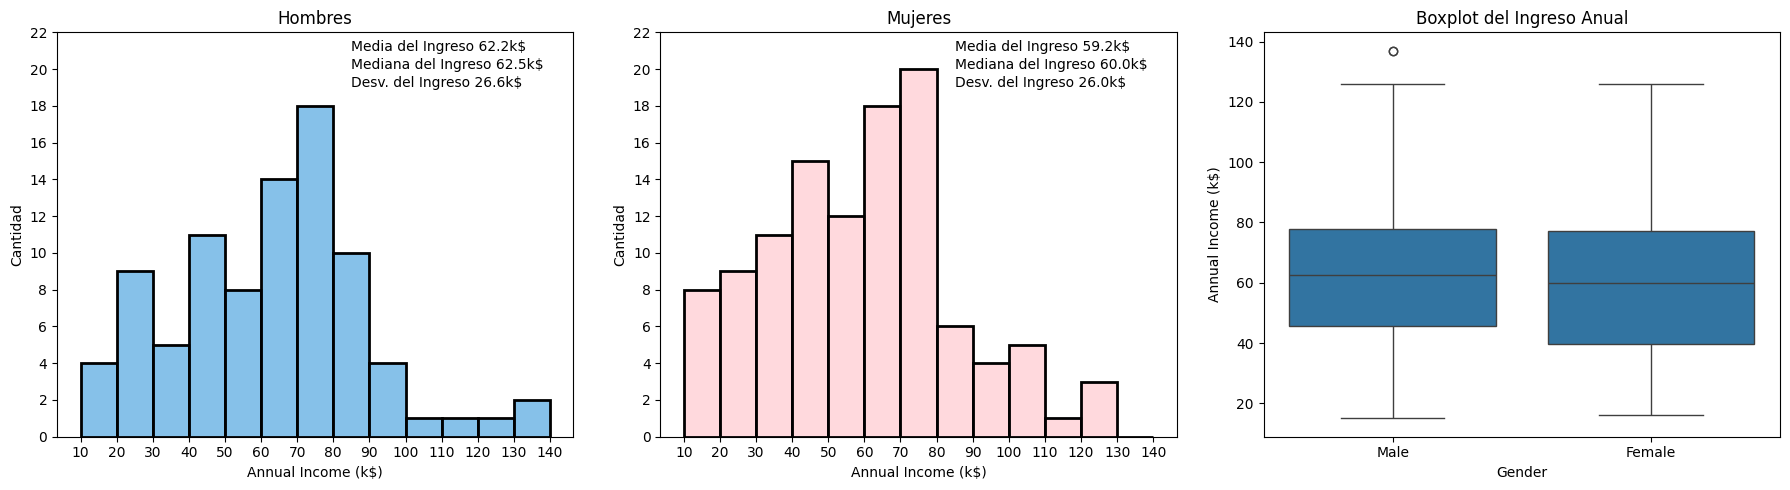

In [ ]:
# Filtrar los datos por género
ingresos_hombres = mall_data[mall_data['Gender'] == 'Male']['Annual Income (k$)']
ingresos_mujeres = mall_data[mall_data['Gender'] == 'Female']['Annual Income (k$)']

# Definir los bins para los ingresos
mi_bins = range(10, 150, 10)

# Crear la figura y los ejes
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# Graficar el histograma para hombres
sns.histplot(ingresos_hombres, bins=mi_bins, color='#5DADE2', ax=ax1,
             edgecolor='k', linewidth=2)
ax1.set_xticks(mi_bins)
ax1.set_yticks(range(0, 24, 2))
ax1.set_ylim(0, 22)
ax1.set_title('Hombres')
ax1.set_ylabel('Cantidad')
ax1.text(85, 21, f'Media del Ingreso {ingresos_hombres.mean():.1f}k$')
ax1.text(85, 20, f'Mediana del Ingreso {ingresos_hombres.median():.1f}k$')
ax1.text(85, 19, f'Desv. del Ingreso {ingresos_hombres.std():.1f}k$')
ax1.grid(False)

# Graficar el histograma para mujeres
sns.histplot(ingresos_mujeres, bins=mi_bins, color='#FFCDD2', ax=ax2,
             edgecolor='k', linewidth=2)
ax2.set_xticks(mi_bins)
ax2.set_yticks(range(0, 24, 2))
ax2.set_ylim(0, 22)
ax2.set_title('Mujeres')
ax2.set_ylabel('Cantidad')
ax2.text(85, 21, f'Media del Ingreso {ingresos_mujeres.mean():.1f}k$')
ax2.text(85, 20, f'Mediana del Ingreso {ingresos_mujeres.median():.1f}k$')
ax2.text(85, 19, f'Desv. del Ingreso {ingresos_mujeres.std():.1f}k$')
ax2.grid(False)

# Graficar el boxplot
sns.boxplot(x='Gender', y='Annual Income (k$)', data=mall_data, ax=ax3)
ax3.set_title('Boxplot del Ingreso Anual')
ax3.grid(False)

plt.tight_layout()
plt.show()

In [ ]:
print('P-value del Kolgomorov-Smirnov test {:.2f}'.format(stats.ks_2samp(ingresos_hombres,ingresos_mujeres)[1]))

P-value del Kolgomorov-Smirnov test 0.78


El Ingreso mas alto de las mujeres es de 70 a 80, tiene una media muy similar con  respecto a los hombres, la desviacion estandar es similar, en los hombres tenemos un ingreso de + de 140k por lo cual influye en la media ya que las mujeres llegan hasta 130k. Y realizando la prueba estadistica los 2 grupos no son estadisticamente diferentes.

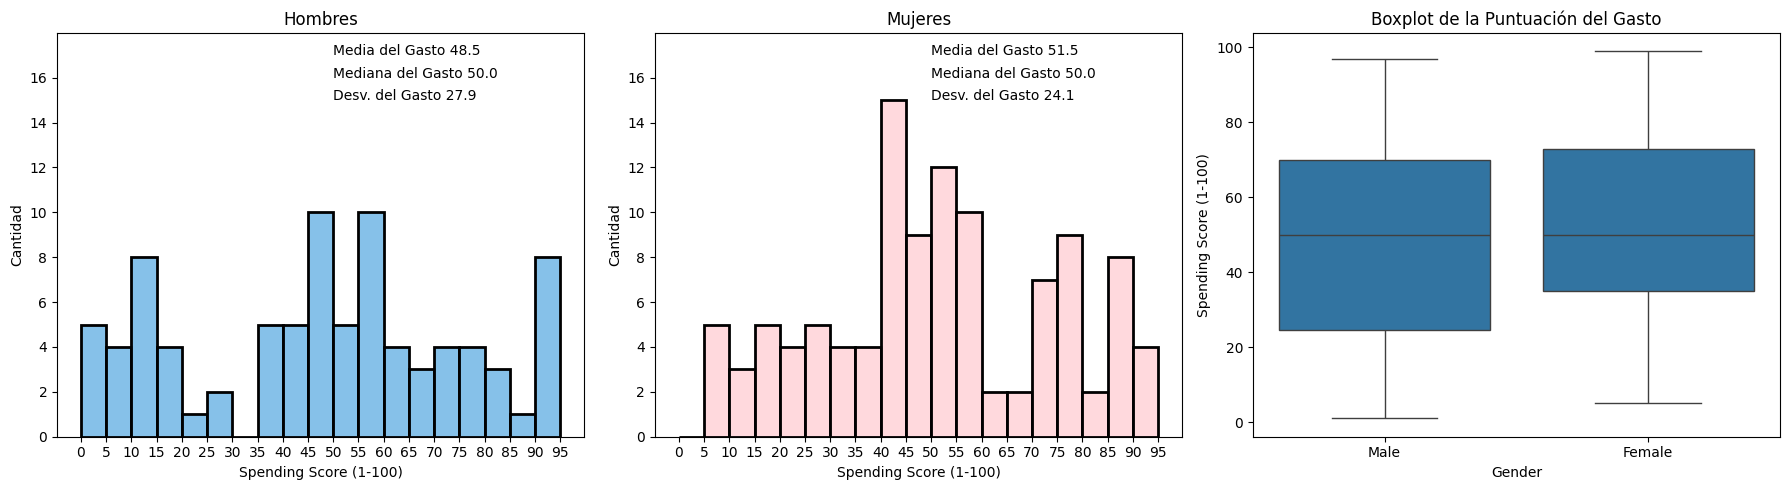

In [ ]:
# Filtrar los datos por género
gasto_hombres = mall_data[mall_data['Gender'] == 'Male']['Spending Score (1-100)']
gasto_mujeres = mall_data[mall_data['Gender'] == 'Female']['Spending Score (1-100)']

# Definir los bins para el gasto
gasto_bins = range(0, 100, 5)

# Crear la figura y los ejes
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# Graficar el histograma para hombres
sns.histplot(gasto_hombres, bins=gasto_bins, color='#5DADE2', ax=ax1,
             edgecolor='k', linewidth=2)
ax1.set_xticks(gasto_bins)
ax1.set_yticks(range(0, 18, 2))
ax1.set_ylim(0, 18)
ax1.set_title('Hombres')
ax1.set_ylabel('Cantidad')
ax1.text(50, 17, f'Media del Gasto {gasto_hombres.mean():.1f}')
ax1.text(50, 16, f'Mediana del Gasto {gasto_hombres.median():.1f}')
ax1.text(50, 15, f'Desv. del Gasto {gasto_hombres.std():.1f}')
ax1.grid(False)

# Graficar el histograma para mujeres
sns.histplot(gasto_mujeres, bins=gasto_bins, color='#FFCDD2', ax=ax2,
             edgecolor='k', linewidth=2)
ax2.set_xticks(gasto_bins)
ax2.set_yticks(range(0, 18, 2))
ax2.set_ylim(0, 18)
ax2.set_title('Mujeres')
ax2.set_ylabel('Cantidad')
ax2.text(50, 17, f'Media del Gasto {gasto_mujeres.mean():.1f}')
ax2.text(50, 16, f'Mediana del Gasto {gasto_mujeres.median():.1f}')
ax2.text(50, 15, f'Desv. del Gasto {gasto_mujeres.std():.1f}')
ax2.grid(False)

# Graficar el boxplot
sns.boxplot(x='Gender', y='Spending Score (1-100)', data=mall_data, ax=ax3)
ax3.set_title('Boxplot de la Puntuación del Gasto')
ax3.grid(False)

plt.tight_layout()
plt.show()

In [ ]:
print('P-value del Kolgomorov-Smirnov test {:.2f}'.format(stats.ks_2samp(gasto_hombres,gasto_mujeres)[1]))

P-value del Kolgomorov-Smirnov test 0.29


El gasto medio de las mujeres es 51.5 que es mas alto que el de los hombres 48.5. El valor p del test de K-S indica que no hay evidencia para rechazar la hipotesis nula, osea que no son muestras distintas.

## Correlaciones

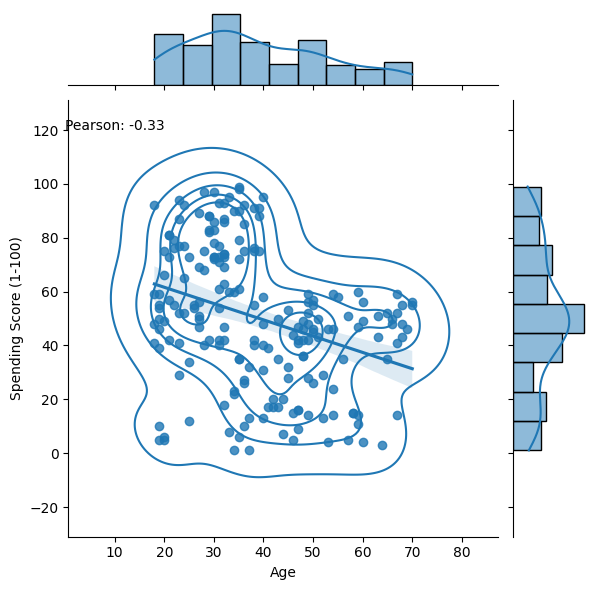

In [ ]:
from scipy.stats import pearsonr

corr, _ = pearsonr(mall_data['Age'], mall_data['Spending Score (1-100)'])

jp = (sns.jointplot(data = mall_data,x =  'Age',y = 'Spending Score (1-100)',
                   kind = 'reg')).plot_joint(sns.kdeplot, zorder = 0, n_levels = 6)

plt.text(0,120, 'Pearson: {:.2f}'.format(corr))
plt.show()

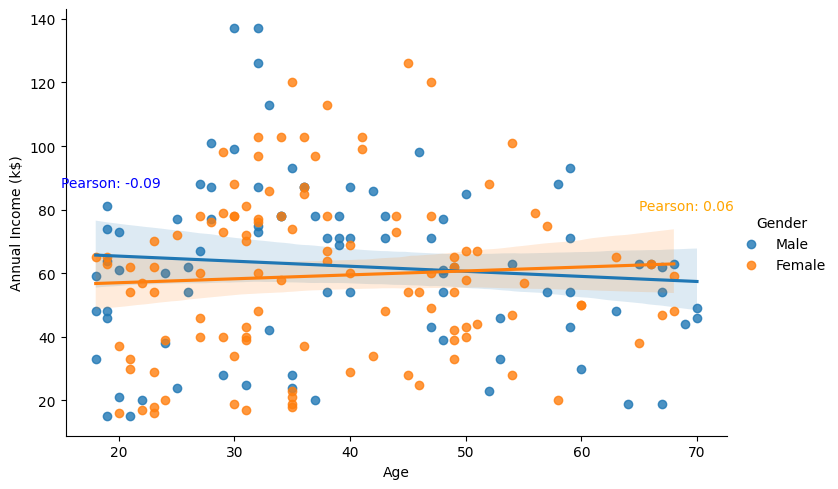

In [ ]:
corr1, _ = pearsonr(hombres_edad.values,ingresos_hombres.values)
corr2, _ = pearsonr(mujeres_edad.values, ingresos_mujeres.values)

sns.lmplot(data = mall_data,x='Age',y='Annual Income (k$)' , hue = 'Gender', aspect = 1.5)

plt.text(15,87, 'Pearson: {:.2f}'.format(corr1), color = "blue")
plt.text(65,80, 'Pearson: {:.2f}'.format(corr2), color = "orange")

plt.show()

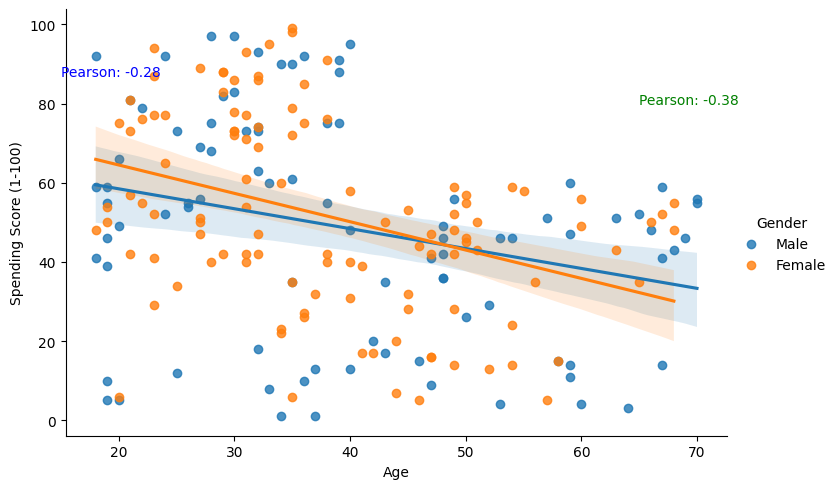

In [ ]:
corr1, _ = pearsonr(hombres_edad.values,gasto_hombres.values)
corr2, _ = pearsonr(mujeres_edad.values, gasto_mujeres.values)

sns.lmplot( data = mall_data,x='Age',y='Spending Score (1-100)', hue = 'Gender', aspect = 1.5)

plt.text(15,87, 'Pearson: {:.2f}'.format(corr1), color = "blue")
plt.text(65,80, 'Pearson: {:.2f}'.format(corr2), color = "green")

plt.show()

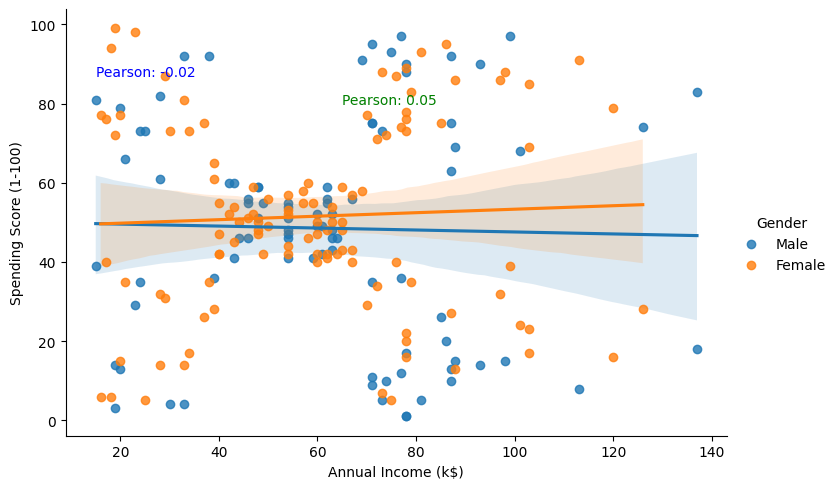

In [ ]:
corr1, _ = pearsonr(ingresos_hombres.values,gasto_hombres.values)
corr2, _ = pearsonr(ingresos_mujeres.values, gasto_mujeres.values)

sns.lmplot( data = mall_data,x='Annual Income (k$)',y='Spending Score (1-100)', hue = 'Gender', aspect = 1.5)

plt.text(15,87, 'Pearson: {:.2f}'.format(corr1), color = "blue")
plt.text(65,80, 'Pearson: {:.2f}'.format(corr2), color = "green")

plt.show()

## Kmeans

El algoritmo de agrupación particional más conocido es K-Means. Se desarrolló de forma independiente en muchos lugares en los años 50 y 60 y ganó gran popularidad debido a su facilidad de implementación, simplicidad y muchos éxitos empíricos (por ejemplo, en negocios, medicina y ciencia).


Hay 3 pasos principales en el algoritmo K-Means (conocido también como algoritmo de Lloyd's):

1. 1.	Divida las muestras en grupos iniciales mediante el uso de puntos de semilla. Las muestras más cercanas a estos puntos de semilla crearán grupos iniciales.
2.	Calcule las distancias de las muestras a los puntos centrales de los grupos (centroides) y asigne las muestras más cercanas a su clúster.
3.	El tercer paso es calcular los centroides de clúster recién creados (actualizados).

A continuación, repita los pasos 2 y 3 hasta que el algoritmo converja.

Como se mencionó anteriormente, el objetivo de K-Means es minimizar la función objetiva (inercia) en todos los grupos. La función objetivo se define como:

Esto se conoce como problema NP-hard, lo que significa que este es un algoritmo codicioso y converge al mínimo local. El costo computacional del algoritmo K-Means de Lloyd es O(kn), donde k es un número de cúmulos y n es un número de muestras. Esto no está mal en comparación con otros algoritmos de agrupación. A pesar de converger generalmente a un mínimo local, la media K es relativamente rápida y cuando los grupos están bien aislados entre sí es probable que converja al mínimo global. Debido a que el resultado de la agrupación depende de los criterios de inicialización, es común ejecutar el análisis para varios puntos de inicialización y elegir el que tenga una inercia resultante mínima. Hay algunas mejoras en el algoritmo que resuelve el problema de los mínimos locales.

En general, se requiere que un usuario del algoritmo K-Means defina tres parámetros principales:

1. **Criterios de inicialización**
En scikit-learn, se implementa un esquema de inicialización inteligente: "k-means++" propuesto por Arthur y Vassilvitskii. Crea centroides iniciales generalmente distantes entre sí aumentando la probabilidad de obtener mejores resultados. También existe la posibilidad de utilizar un generador de puntos aleatorios. Hay esfuerzos en curso para crear el método de siembra más eficiente para el algoritmo K-Means, uno de ellos se basa en el análisis de componentes independientes.

2. **El numero de cluster**
que seleccionan varios clústeres es la parte más difícil de configurar este algoritmo. No hay criterios matemáticos estrictos para esto y se han desarrollado muchos enfoques heurísticos / simplificados. Uno de los más simples y populares es el método del codo que se muestra en este análisis. Además, también se utilizará una puntuación de silueta. También hay otras opciones, a menudo avanzadas, para elegir el número óptimo de clústeres (sin embargo, no se utilizan en este portátil y no se implementan en sklearn).

* Longitud Minima del Mensaje (MML)
* Longitud minima descripcion (CDM)
* Criterio de informacion de Bayes (BIC)
* Akaike Information Criterion (AIC)
* Proceso de Dirichlet
* Estadisticas de Brechas

Conclusiones sobre Kmeans:
1.	Se utilizan distancias euclidianas
2.	Se debe definir el número de clústeres para el algoritmo
3.	El centroide se calcula utilizando la distancia media a los miembros del clúster
4.	Los clusters se asumen isotrópicos y convexos
5.	Algoritmo estocástico: los resultados dependen de los criterios de inicialización
6.	Crea grupos de varianza igual (minimiza la inercia)
7.	Propenso a la "maldición de la dimensionalidad"
8.	Se puede ejecutar en paralelo, por lo que escala bien


## Como funciona

El algoritmo de los K-means tienen como objetivo elegir ‘K’ centroides que reduzcan al mínimo la inercia:


El funcionamiento de este algoritmo comienza eligiendo un centroide para cada uno de los ‘K’ Clusters. El método de elección de estos centroides puede ser cualquiera; siendo los dos más comunes, el inicializarlo de forma aleatoria o el de elegir ‘K’ objetos del data set, bien sea de forma aleatoria o haciendo un pre-procesamiento de los datos. Lo recomendable sería la segunda opción e inicializar estos Clusters con objetos del data set. Una vez inicializados los centroides, el algoritmo continua alternando los dos siguientes pasos (asignación y actualización) de forma iterativa hasta que los centroides converjan:

* Asignación: Se asigna cada objeto al Cluster más cercano, aplicando alguna medida de distancia (como por ejemplo la distancia euclídea) entre el objeto y el centroide del Cluster.
* Actualización: Calcula los nuevos centroides, haciendo la media de los objetos que forman el Cluster.

Se considera que el algoritmo finaliza cuando los centroide convergen o cuando la diferencia entre el valor de los centroides de una iteración a otra es inferior a un determinado umbral.

El algoritmo empleado es:
* Especificar el número K de clusters que se quieren crear.
* Seleccionar de forma aleatoria k observaciones del set de datos como centroides iniciales.

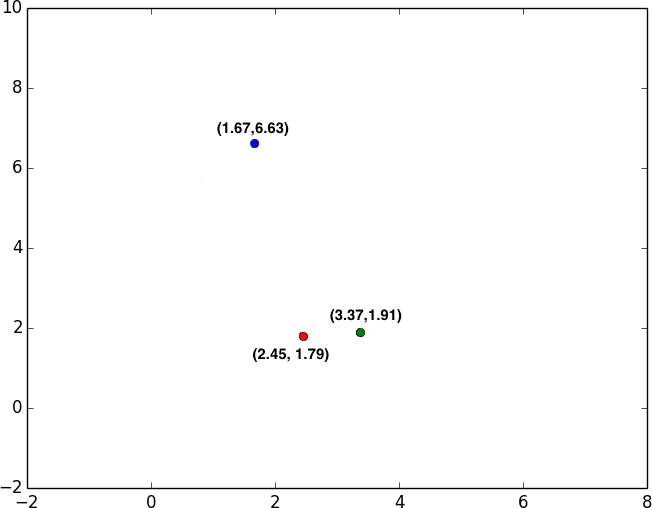

* Asignar cada una de las observaciones al centroide más cercano.

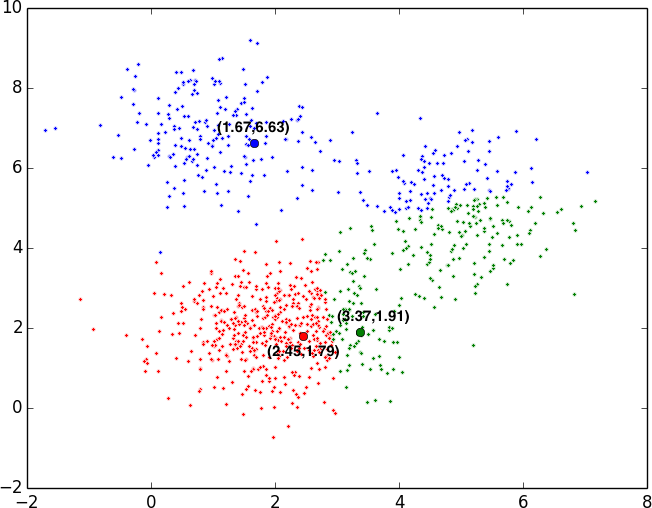

* Para cada uno de los K clusters generados en el paso 3, recalcular su centroide.

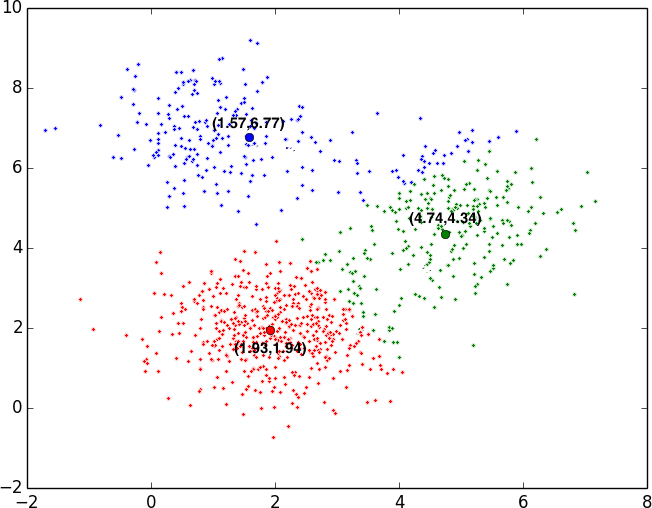

* Repetir los pasos 3 y 4 hasta que las asignaciones no cambien o se alcance el número máximo de iteraciones establecido.


Este algoritmo garantiza que, en cada paso, se reduzca la intra-varianza total de los clusters hasta alcanzar un óptimo local. Debido a que el algoritmo de K-means no evalúa todas las posibles distribuciones de las observaciones sino solo parte de ellas, los resultados obtenidos dependen de la asignación aleatoria inicial (paso 2). Por esta razón, es importante ejecutar el algoritmo varias veces (25-50), cada una con una asignación aleatoria inicial distinta, y seleccionar aquella que haya conseguido una menor varianza total.

### Ventajas y desventajas
* K-means es uno de los métodos de clustering más utilizados. Destaca por la sencillez y velocidad de su algoritmo, sin embargo, presenta una serie de limitaciones que se deben tener en cuenta.
* Requiere que se indique de antemano el número de clusters que se van a crear. Esto puede ser complicado si no se dispone de información adicional sobre los datos con los que se trabaja. Se han desarrollado varias estrategias para ayudar a identificar potenciales valores óptimos de K (elbow, shilouette), pero todas ellas son orientativas.
* Dificultad para detectar clusters alargados o con formas irregulares.
* Las agrupaciones resultantes pueden variar dependiendo de la asignación aleatoria inicial de los centroides. Para minimizar este problema, se recomienda repetir el proceso de clustering entre 25-50 veces y seleccionar como resultado definitivo el que tenga menor suma total de varianza interna. Aun así, solo se puede garantizar la reproducibilidad de los resultados si se emplean semillas.
* Presenta problemas de robustez frente a outliers.

## Aplicacion del Modelo KMEANS

1. El primer paso en un análisis de clustering es importar K-Means desde la biblioteca sklearn.

In [ ]:
from sklearn.cluster import KMeans

Para la agrupación en clústeres solo se utilizan columnas numéricas. Como se mencionó al principio, la variable binaria género no se usará aquí.

In [ ]:
# Seleccionar todas las columnas numéricas
X_numerics = mall_data.select_dtypes(include='number')

# Excluir la columna 'CustomerID'
X_numerics = X_numerics.drop(columns=['CustomerID'])

Para encontrar un número adecuado de grupos, se utilizará el método del codo. En este método para este caso, se calculará la inercia para un número de grupos entre 2 y 10. La regla es elegir el número de grupos donde se ve una torcedura o "un codo" en el gráfico.

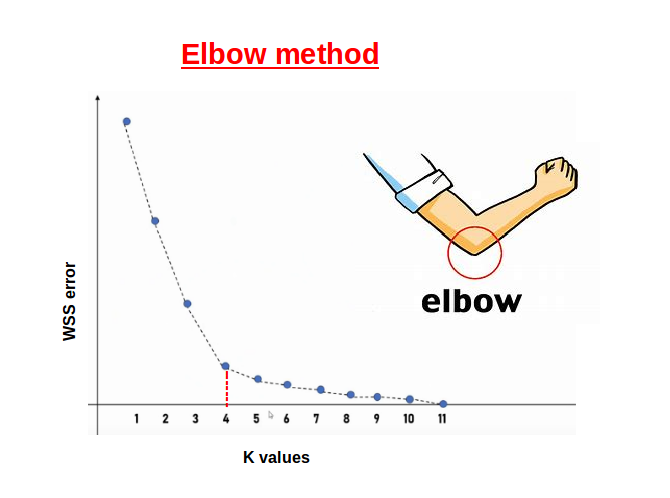

### **El Método del Codo (Elbow Method)**

El Método del Codo es una técnica utilizada para determinar el número óptimo de clústeres en algoritmos de agrupamiento como K-Means. Ayuda a identificar el punto donde agregar más clústeres no proporciona una mejora significativa en la variabilidad explicada por el modelo, evitando así el sobreajuste.

Concepto Básico
En el algoritmo K-Means, el objetivo es minimizar la suma de las distancias al cuadrado (SSE, Sum of Squared Errors) entre los puntos de datos y sus respectivos centroides de clústeres:

WCSS

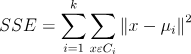

Donde:

* 𝑘 es el número de clústeres.
* 𝐶𝑖 es el conjunto de puntos en el clúster 𝑖.
* 𝜇𝑖 es el centroide del clúster 𝑖.
*   es la distancia euclidiana al cuadrado entre el punto 𝑥 y el centroide 𝜇𝑖.

### **Procedimiento del Método del Codo**
1. **Ejecutar el algoritmo de agrupamiento** (por ejemplo, K-Means) para diferentes valores de 𝑘 (número de clústeres), típicamente en un rango de 1 a 10 o más.

2. **Calcular la SSE** para cada valor de 𝑘. Esto implica calcular la suma de las distancias al cuadrado de cada punto al centroide de su clúster.

3. **Graficar el SSE contra el número de clústeres 𝑘:**

* En el eje X: Número de clústeres 𝑘.
* En el eje Y: SSE correspondiente.

4. **Identificar el "codo" en la gráfica:**

* El punto donde la disminución de SSE se vuelve menos pronunciada.
* Representa el número óptimo de clústeres, ya que agregar más clústeres no resulta en una mejora significativa de la variabilidad explicada.

In [ ]:
import warnings
warnings.filterwarnings("ignore")

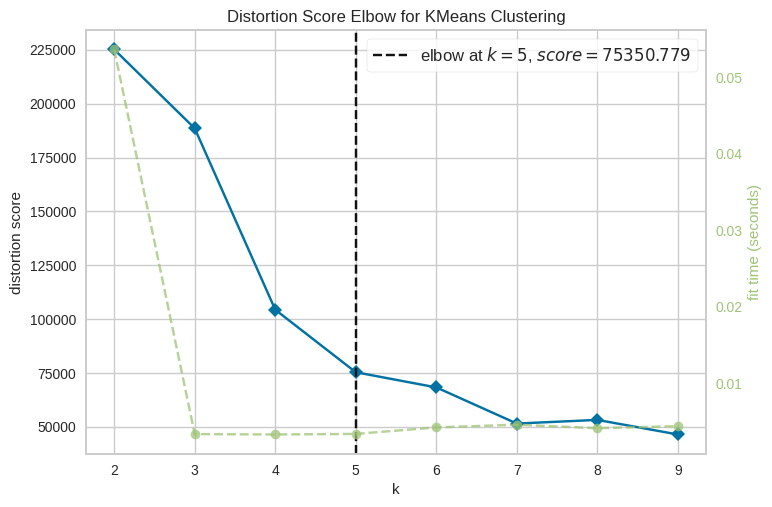

In [ ]:
from yellowbrick.cluster import KElbowVisualizer

modelo = KMeans(random_state=1)
visual = KElbowVisualizer(modelo, k=(2,10))

visual.fit(X_numerics)
visual.show()
plt.show()

El gráfico anterior muestra la reducción de una puntuación de distorsión a medida que aumenta el número de grupos. Sin embargo, no hay un "codo" claro visible. El algoritmo subyacente sugiere 5 clústeres. Una elección de 5 o 6 grupos parece ser justa.

Otra forma de elegir el mejor número de clústeres es trazar la puntuación de silhuette en función del número de clústeres. Veamos los resultados.


### **Método de la Silueta (Silhouette Method)**

El Método de la Silueta es una técnica utilizada para evaluar la calidad de los clústeres formados por un algoritmo de agrupamiento. Proporciona una medida de qué tan bien se asigna cada punto de datos a su clúster, en comparación con otros clústeres. Es particularmente útil para determinar el número óptimo de clústeres 𝑘.

Para cada punto de datos 𝑖, se calcula un coeficiente de silueta 𝑠(𝑖) que refleja qué tan similar es 𝑖 a los puntos de su propio clúster en comparación con los puntos de otros clústeres.

El coeficiente de silueta 𝑠(𝑖) se define como:

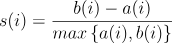

Donde:

* 𝑎(𝑖) es la distancia media entre el punto 𝑖 y todos los demás puntos en el mismo clúster.
* 𝑏(𝑖) es la distancia media entre el punto 𝑖 y todos los puntos en el clúster más cercano al que 𝑖 no pertenece.

**Interpretación del Coeficiente de Silueta**
1. 𝑠(𝑖) cercano a 1:

* El punto está bien agrupado.
* La distancia media al clúster propio (𝑎(𝑖)) es mucho menor que la distancia media al clúster más cercano (𝑏(𝑖)).

2. 𝑠(𝑖) cercano a 0:

* El punto está en el límite entre dos clústeres.
* 𝑎(𝑖) y 𝑏(𝑖) son aproximadamente iguales.

3. 𝑠(𝑖) cercano a -1:

* El punto podría estar mal asignado.
* 𝑎(𝑖) es mayor que 𝑏(𝑖).

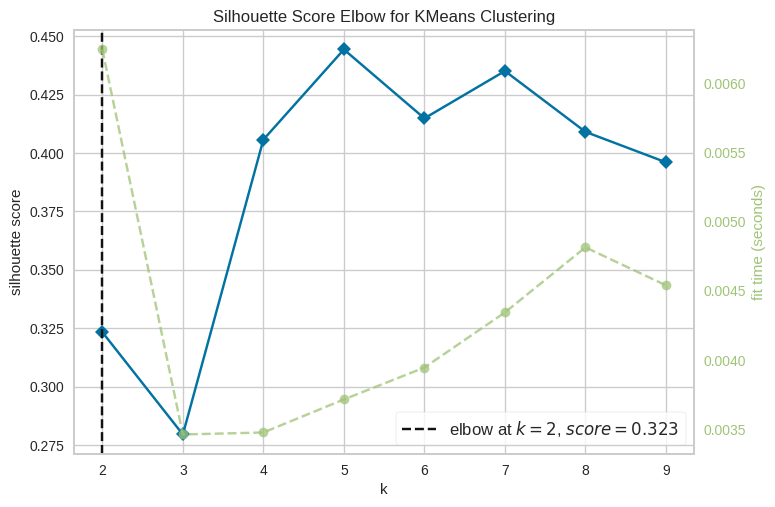

In [ ]:
modelo = KMeans(random_state=1)
visual = KElbowVisualizer(modelo, k=(2,10), metric='silhouette')

visual.fit(X_numerics)
visual.show()
plt.show()

El método de puntuación de silueta indica que las mejores opciones serían 5 o 6 grupos. Comparemos ambos.

### **Automatización**

#### 5 Cluster

In [ ]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline

def evaluar_kmeans_multimetrica(data, k_manual=None, k_min=2, k_max=10, random_state=42):
    """
    Evalúa automáticamente KMeans con múltiples métricas para distintos valores de k
    y selecciona el mejor según un ranking combinado. Permite también un valor manual de k.

    Parámetros:
    - data: datos de entrada (DataFrame o ndarray).
    - k_manual: valor fijo de k. Si se proporciona, no se evalúan métricas automáticas.
    - k_min, k_max: rango de k a evaluar si no se da k_manual.
    - random_state: semilla de reproducibilidad.

    Retorna:
    - df_resultados: tabla con los valores de las métricas por cada k.
    - mejor_k: valor óptimo de k seleccionado.
    - modelo_kmeans: modelo entrenado con el mejor_k.
    - etiquetas: etiquetas asignadas al dataset.
    """

    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(data)

    if k_manual is not None:
        modelo = KMeans(n_clusters=k_manual, random_state=random_state)
        etiquetas = modelo.fit_predict(X_scaled)
        return None, k_manual, modelo, etiquetas

    resultados = []

    for k in range(k_min, k_max + 1):
        modelo = KMeans(n_clusters=k, random_state=random_state)
        etiquetas = modelo.fit_predict(X_scaled)
        inertia = modelo.inertia_
        silhouette = silhouette_score(X_scaled, etiquetas)
        ch_score = calinski_harabasz_score(X_scaled, etiquetas)

        resultados.append({
            'k': k,
            'inercia': inertia,
            'silhouette': silhouette,
            'calinski_harabasz': ch_score
        })

    df = pd.DataFrame(resultados)

    # Rankings individuales
    df['rank_inercia'] = df['inercia'].rank(ascending=True)
    df['rank_silhouette'] = df['silhouette'].rank(ascending=False)
    df['rank_ch'] = df['calinski_harabasz'].rank(ascending=False)

    # Ranking combinado
    df['ranking_total'] = df[['rank_inercia', 'rank_silhouette', 'rank_ch']].mean(axis=1)

    # Selección de mejor k con desempate por menor k
    mejores = df[df['ranking_total'] == df['ranking_total'].min()]
    mejor_k = int(mejores.sort_values('k').iloc[0]['k'])

    # Entrenamiento final con mejor k
    modelo_kmeans = KMeans(n_clusters=mejor_k, random_state=random_state)
    etiquetas_finales = modelo_kmeans.fit_predict(X_scaled)

    print(f"Mejor k seleccionado: {mejor_k}")

    return df.sort_values('ranking_total'), mejor_k, modelo_kmeans, etiquetas_finales



In [ ]:
# Evaluación automática
df_kmeans, k_auto, modelo_final, etiquetas = evaluar_kmeans_multimetrica(X_numerics)

# Mostrar tabla de evaluación
display(df_kmeans)

Mejor k seleccionado: 6


,k,inercia,silhouette,calinski_harabasz,rank_inercia,rank_silhouette,rank_ch,ranking_total
4,6,8.415634,0.419179,133.638294,5.0,2.0,1.0,2.666667
5,7,7.615036,0.420766,125.820901,4.0,1.0,4.0,3.000000
8,10,5.499439,0.366104,122.464769,1.0,5.0,5.0,3.666667
3,5,10.438009,0.404210,125.931039,6.0,3.0,3.0,4.000000
6,8,7.034385,0.367450,118.407805,3.0,4.0,6.0,4.333333
7,9,6.482621,0.362913,113.871816,2.0,8.0,7.0,5.666667
0,2,22.560775,0.365250,130.246415,9.0,7.0,2.0,6.000000
2,4,14.879180,0.365864,98.893690,7.0,6.0,9.0,7.333333
1,3,17.559658,0.340279,111.301690,8.0,9.0,8.0,8.333333


In [ ]:
KM6_clustered = X_numerics.copy()
KM6_clustered['Cluster'] = etiquetas

In [ ]:
X_categoricas =  mall_data[['CustomerID', 'Gender']]

datos_final = pd.concat([X_categoricas,KM6_clustered],axis = 1)

datos_final

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,2
1,2,Male,21,15,81,4
2,3,Female,20,16,6,2
3,4,Female,23,16,77,4
4,5,Female,31,17,40,2
...,...,...,...,...,...,...
195,196,Female,35,120,79,1
196,197,Female,45,126,28,3
197,198,Male,32,126,74,1
198,199,Male,32,137,18,3


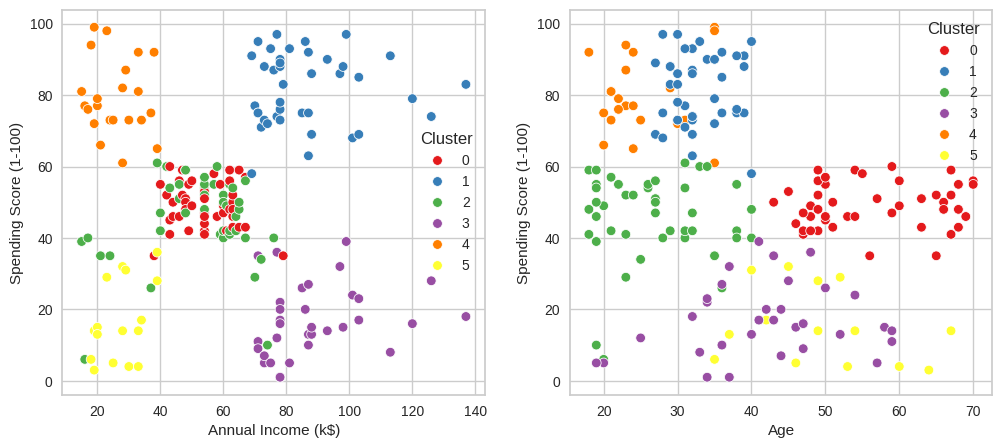

In [ ]:
fig1, (axes) = plt.subplots(1,2,figsize=(12,5))


scat_1 = sns.scatterplot( data=KM6_clustered,x= 'Annual Income (k$)', y= 'Spending Score (1-100)',
                hue='Cluster', ax=axes[0], palette='Set1', legend='full')

sns.scatterplot(data=KM6_clustered,x= 'Age', y= 'Spending Score (1-100)',
                hue='Cluster', palette='Set1', ax=axes[1], legend='full')
plt.show()

El algoritmo K-Means generó los siguientes 5 clústeres:


*	clientes con  bajos ingresos anuales y alto puntaje de gasto
*	clientes con  ingresos anuales medios y  puntaje de gasto medio
*	clientes con altos ingresos anuales y bajo puntaje de gasto
*	clientes con altos ingresos anuales y alto puntaje de gasto
*	clientes con  bajos ingresos anuales y bajo puntaje de gasto

No hay grupos distintos en términos de edad de los clientes.


**Tamaño de los Cluster**

In [ ]:
KM_clust_sizes = KM6_clustered.groupby('Cluster').size().to_frame()
KM_clust_sizes.columns = ["Tamanio_KMeans"]
KM_clust_sizes

,Tamanio_KMeans
Cluster,
0,45
1,40
2,44
3,33
4,22
5,16


El clúster más grande es un grupo número 2 con 79 observaciones (clientes "medio-medio"). Hay dos de los más pequeños, cada uno de los cuales contiene 23 observaciones (grupos 3 "alto-alto" y grupo 0 clientes "bajo-alto"). A continuación hay una proyección 3D de 5 clústeres generados. No es muy útil en términos de visualización en modo estático, pero si ejecuta el código en un entorno interactivo (por ejemplo, Spyder) ¡puede rotarlo!

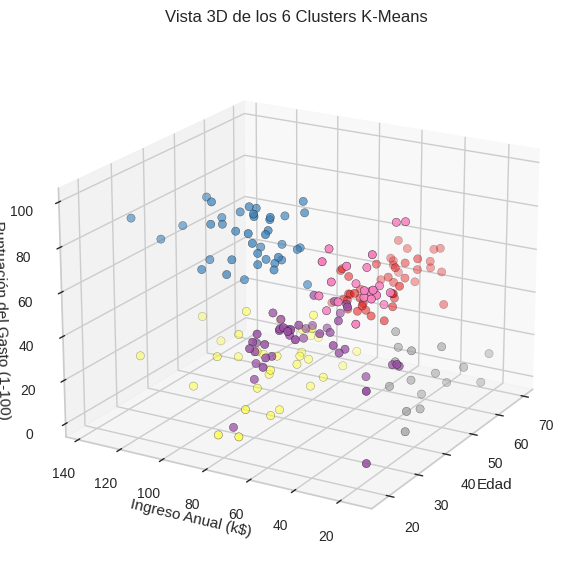

In [ ]:
import matplotlib.pyplot as plt

# Crear la figura y los ejes 3D
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection='3d', elev=20, azim=210)

# Graficar el scatter plot 3D
scatter = ax.scatter(
    KM6_clustered['Age'],
    KM6_clustered['Annual Income (k$)'],
    KM6_clustered['Spending Score (1-100)'],
    c=KM6_clustered['Cluster'],
    s=35,
    edgecolor='k',
    cmap=plt.cm.Set1
)

# Configurar las etiquetas de los ejes
ax.set_xlabel('Edad')
ax.set_ylabel('Ingreso Anual (k$)')
ax.set_zlabel('Puntuación del Gasto (1-100)')
ax.set_title('Vista 3D de los 6 Clusters K-Means')

# Mostrar el gráfico
plt.show()


In [ ]:
import plotly as py
import plotly.graph_objs as go

def tracer(db, n, name):
    '''
    Esta función devuelve un objeto de seguimiento para Plotly
    '''
    return go.Scatter3d(
        x = db[db['Cluster']==n]['Age'],
        y = db[db['Cluster']==n]['Spending Score (1-100)'],
        z = db[db['Cluster']==n]['Annual Income (k$)'],
        mode = 'markers',
        name = name,
        marker = dict(
            size = 5
        )
     )

trace0 = tracer(KM6_clustered, 0, 'Cluster 0')
trace1 = tracer(KM6_clustered, 1, 'Cluster 1')
trace2 = tracer(KM6_clustered, 2, 'Cluster 2')
trace3 = tracer(KM6_clustered, 3, 'Cluster 3')
trace4 = tracer(KM6_clustered, 4, 'Cluster 4')
trace5 = tracer(KM6_clustered, 5, 'Cluster 5')

data = [trace0, trace1, trace2, trace3, trace4,trace5]

layout = go.Layout(
    title = 'Clusters by K-Means',
    scene = dict(
            xaxis = dict(title = 'Age'),
            yaxis = dict(title = 'Spending Score'),
            zaxis = dict(title = 'Annual Income')
        )
)

fig = go.Figure(data=data, layout=layout)
py.offline.iplot(fig)

Para comprobar la calidad de cada racimo podemos examinar la gráfica de Silhuette.

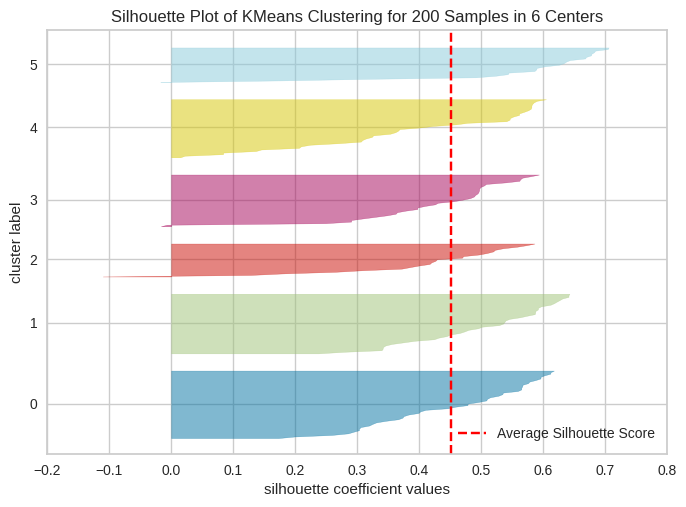

In [ ]:
from yellowbrick.cluster import SilhouetteVisualizer
model = KMeans(n_clusters=6, random_state=0)
visualizer = SilhouetteVisualizer(model, colors='yellowbrick')
visualizer.fit(X_numerics)
visualizer.show()
plt.show()

# DBSCAN

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) y muestra su implementación a la segmentación de clientes de centros comerciales.

**Descripción**

DBSCAN significa Agrupación espacial basada en la densidad de aplicaciones con ruido y es uno de los algoritmos de agrupación en clústeres implementados en la biblioteca scikit-learn. Fue propuesto por Martin Ester, Hans-Peter Kriegel, Jörg Sander y Xiaowei Xu en 1996 en su famoso artículo "A Density-Based Algorithm for Discovering Clusters in Large Spatial Database with Noise".
Como el nombre del documento sugiere, la idea central de DBSCAN gira en torno al concepto de regiones densas. La suposición es que los cúmulos naturales están compuestos de puntos densamente ubicados. Esto requiere la definición de "región densa". Para ello se requieren dos parámetros para el algoritmo DBSCAN.

*	Eps, ε - distancia
*	MinPts - Número mínimo de puntos a distancia Eps

Opcionalmente, la métrica de distancia puede ser especificada por un usuario, pero generalmente se implementa la distancia euclidiana (como en scikit learn).
Por lo tanto, una "región densa" es creada por un número mínimo de puntos dentro de la distancia entre todos ellos, Eps. Los puntos que se encuentran dentro de esta distancia pero no cerca del número mínimo de otros puntos se tratan como "puntos fronterizos". Los restantes son ruido o valores atípicos. Esto se muestra en la imagen de abajo (para MinPts=3). Los puntos rojos (D) se encuentran en una "región densa": cada uno tiene un mínimo de 3 vecinos dentro de la distancia Eps. Los puntos verdes (B) son fronterizos: tienen un vecino a poca distancia Pero menos de 3. El punto azul (O) es un valor atípico: no hay vecinos a poca distancia Eps.


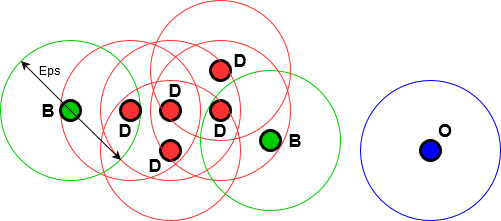

Ventajas de este enfoque:

1.	encuentra el número de clústeres en sí, basándose en los parámetros eps y MinPts
2.	Puede diferenciar grupos alargados o grupos rodeados por otros grupos en contra de, por ejemplo, K-Means donde los cúmulos son siempre convexos.
3.	También es capaz de encontrar puntos que no encajan en ningún clúster: detecta valores atípicos.

El mayor inconveniente de DBSCAN:

1.	Alto gasto computacional de O(n log(n)) promedio proveniente de la necesidad de ejecutar una consulta de vecindad para cada punto.
2.	Identifica mal los grupos con varias densidades


In [ ]:
from sklearn.cluster import DBSCAN

En DBSCAN hay dos hiperparámetros principales:

1.	Eps
2.	min_samples

Es difícil decir arbitrariamente qué valores funcionarán mejor. Por lo tanto, primero crearé una matriz de combinaciones investigadas.


In [ ]:
from itertools import product

eps_values = np.arange(8,13,0.25) # valores eps a investigar
min_samples = np.arange(3,10) # min_samples valores a investigar

DBSCAN_params = list(product(eps_values, min_samples))

Debido a que DBSCAN crea clústeres en sí mismo en función de esos dos parámetros, verifiquemos la cantidad de clústeres generados.

In [ ]:
from sklearn.metrics import silhouette_score

no_de_clusters = []
sil_score = []

for p in DBSCAN_params:
    DBS_clustering = DBSCAN(eps=p[0], min_samples=p[1]).fit(X_numerics)
    no_de_clusters.append(len(np.unique(DBS_clustering.labels_)))
    sil_score.append(silhouette_score(X_numerics, DBS_clustering.labels_))

Un diagrama de calor a continuación muestra cuántos clústeres generó el algoritmo DBSCAN para las combinaciones de parámetros respectivas.

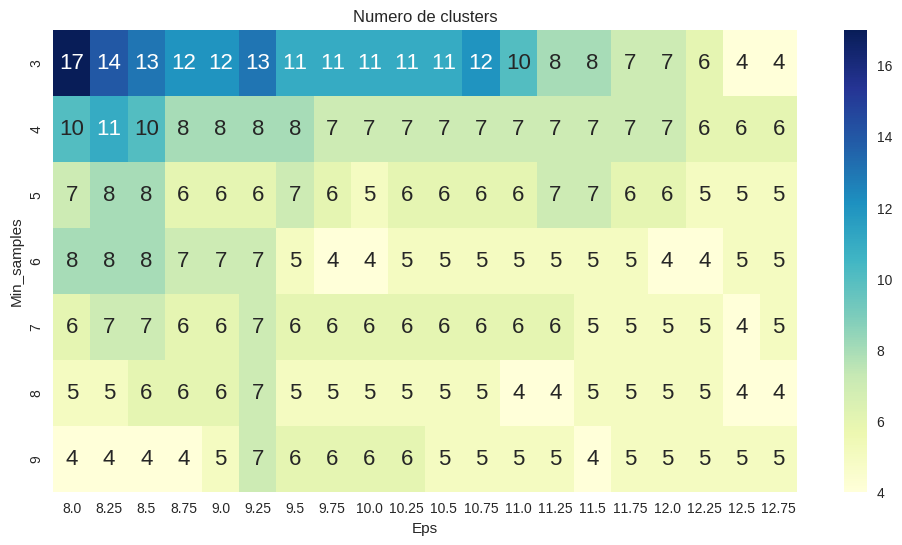

In [ ]:
tmp = pd.DataFrame.from_records(DBSCAN_params, columns =['Eps', 'Min_samples'])
tmp['No_de_clusters'] = no_de_clusters

pivot_1 = pd.pivot_table(tmp, values='No_de_clusters', index='Min_samples', columns='Eps')

fig, ax = plt.subplots(figsize=(12,6))
sns.heatmap(pivot_1, annot=True,annot_kws={"size": 16}, cmap="YlGnBu", ax=ax)
ax.set_title('Numero de clusters')
plt.show()

El diagrama de calor anterior muestra que la cantidad de grupos varía de 17 a 4. Sin embargo, la mayoría de las combinaciones dan de 4 a 7 grupos. Para decidir qué combinación elegir, usaré una métrica: una puntuación de silueta y la trazaré nuevamente como un mapa de calor.

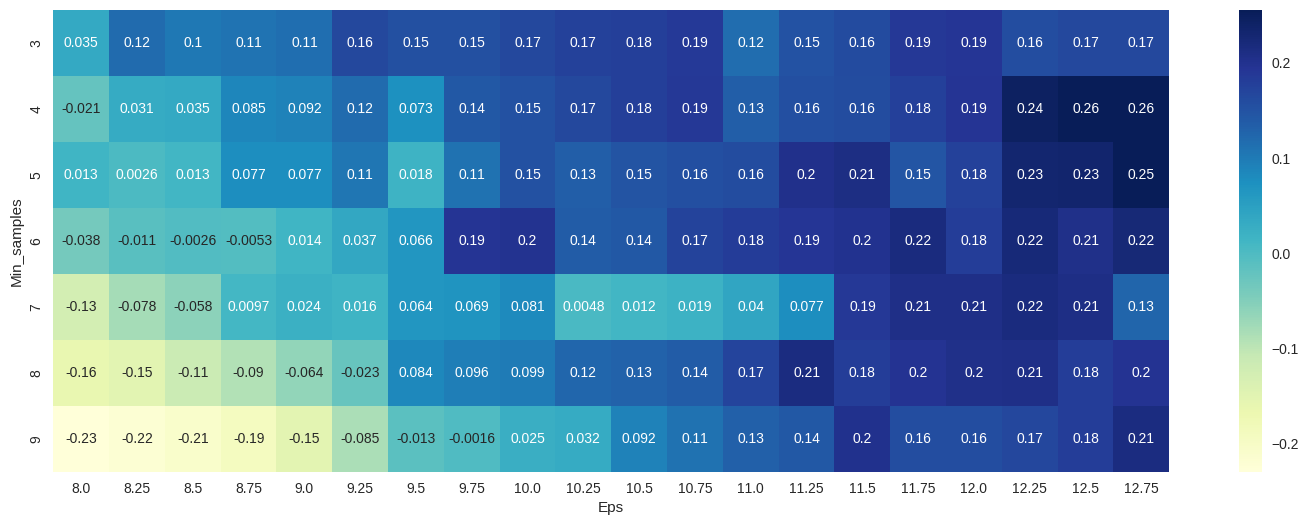

In [ ]:
tmp = pd.DataFrame.from_records(DBSCAN_params, columns =['Eps', 'Min_samples'])
tmp['Sil_score'] = sil_score

pivot_1 = pd.pivot_table(tmp, values='Sil_score', index='Min_samples', columns='Eps')

fig, ax = plt.subplots(figsize=(18,6))
sns.heatmap(pivot_1, annot=True, annot_kws={"size": 10}, cmap="YlGnBu", ax=ax)
plt.show()


El máximo global es 0,26 para eps=12,5 y min_samples=4.

### **Automatización**

In [ ]:
def evaluar_dbscan_pipeline(
    data,
    eps_min=1, eps_max=13, eps_step=0.25,
    min_samples_min=3, min_samples_max=9, min_samples_step=1
):
    mejor_score = -1
    mejor_eps = None
    mejor_min_samples = None
    mejor_pipeline = None
    mejor_labels = None
    resultados = []

    for eps in np.arange(eps_min, eps_max + eps_step, eps_step):
        for min_samples in np.arange(min_samples_min, min_samples_max + 1, min_samples_step):
            modelo = DBSCAN(eps=eps, min_samples=int(min_samples))
            labels = modelo.fit_predict(data)
            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

            # Validar que hay más de un clúster real
            if n_clusters > 1:
                score = silhouette_score(data, labels)
                resultados.append({
                    'eps': eps,
                    'min_samples': int(min_samples),
                    'silhouette': score,
                    'n_clusters': n_clusters
                })
                if score > mejor_score:
                    mejor_score = score
                    mejor_eps = eps
                    mejor_min_samples = int(min_samples)
                    mejor_labels = labels
                    mejor_pipeline = Pipeline([
                        ('dbscan', DBSCAN(eps=eps, min_samples=int(min_samples)))
                    ])
    resultados_df = pd.DataFrame(resultados)
    return resultados_df, mejor_pipeline, mejor_eps, mejor_min_samples, mejor_score, mejor_labels

In [ ]:
resultados_dbscan, pipeline_optimo, mejor_eps, mejor_min_samples, mejor_score, etiquetas_optimas = evaluar_dbscan_pipeline(X_numerics)

if pipeline_optimo is None:
    print("No se encontró ninguna combinación de DBSCAN con al menos 2 clusters.")
else:
    print(f" combinación encontrada: eps={mejor_eps:.2f}, min_samples={mejor_min_samples}, Silhouette={mejor_score:.2f}, N clusters={len(set(etiquetas_optimas)) - (1 if -1 in etiquetas_optimas else 0)}")

 combinación encontrada: eps=12.50, min_samples=4, Silhouette=0.26, N clusters=5


In [ ]:
# Crear DataFrame con etiquetas
DBSCAN_clustered = X_numerics.copy()
DBSCAN_clustered['Cluster'] = etiquetas_optimas


Comprobación de tamaños de clústeres.

In [ ]:
DBSCAN_clust_sizes = DBSCAN_clustered.groupby('Cluster').size().to_frame()
DBSCAN_clust_sizes.columns = ["DBSCAN_size"]
DBSCAN_clust_sizes

,DBSCAN_size
Cluster,
-1,18
0,112
1,8
2,34
3,24
4,4



DBSCAN creó 5 grupos más el grupo de valores atípicos (-1). Los tamaños de los conglomerados 0-4 varían significativamente; algunos tienen solo 4 u 8 observaciones. Hay 18 valores atípicos.

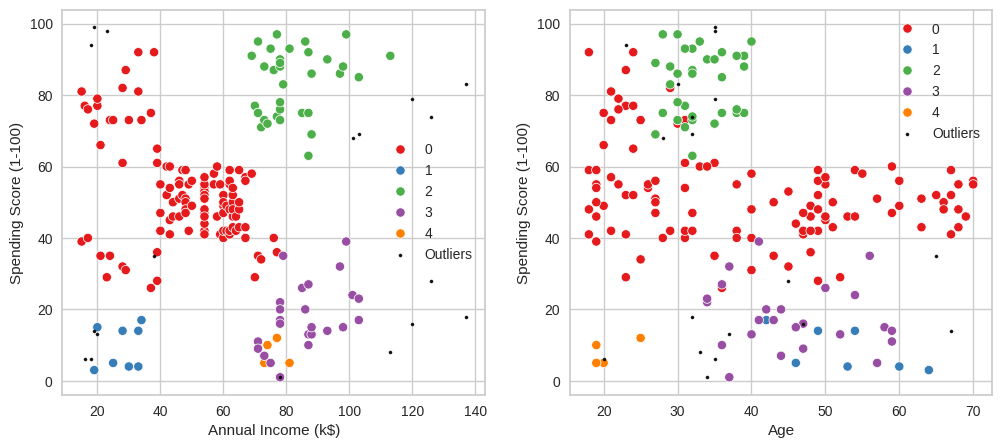

In [ ]:
# Filtrar los outliers (ruido) del cluster -1
outliers = DBSCAN_clustered[DBSCAN_clustered['Cluster'] == -1]

# Crear los subplots
fig2, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico 1: Ingreso Anual vs Puntuación de Gasto (sin outliers)
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)',
                data=DBSCAN_clustered[DBSCAN_clustered['Cluster'] != -1],
                hue='Cluster', palette='Set1', ax=axes[0], legend='full', s=45)

# Gráfico 2: Edad vs Puntuación de Gasto (sin outliers)
sns.scatterplot(x='Age', y='Spending Score (1-100)',
                data=DBSCAN_clustered[DBSCAN_clustered['Cluster'] != -1],
                hue='Cluster', palette='Set1', ax=axes[1], legend='full', s=45)

# Añadir los outliers al Gráfico 1
axes[0].scatter(outliers['Annual Income (k$)'], outliers['Spending Score (1-100)'],
                s=5, label='Outliers', c='k')

# Añadir los outliers al Gráfico 2
axes[1].scatter(outliers['Age'], outliers['Spending Score (1-100)'],
                s=5, label='Outliers', c='k')

# Ajustar leyendas y formato
axes[0].legend()
axes[1].legend()

plt.setp(axes[0].get_legend().get_texts(), fontsize='10')
plt.setp(axes[1].get_legend().get_texts(), fontsize='10')

# Mostrar los gráficos
plt.show()


El gráfico anterior muestra que hay algunos valores atípicos: estos puntos no cumplen con los requisitos de distancia y muestras mínimas para ser reconocidos como un grupo.

## Affinity Propagation

Affinity Propagation fue publicado por primera vez en 2007 por Brendan Frey y Delbert Dueck en Science. A diferencia de otros métodos tradicionales de agrupación en clústeres, Affinity Propagation no requiere que especifique la cantidad de clústeres.

En términos sencillos, en Affinity Propagation, cada punto de datos envía mensajes a todos los demás puntos informando a sus objetivos sobre el atractivo relativo de cada objetivo para el remitente. Luego, cada objetivo responde a todos los remitentes con una respuesta que informa a cada remitente de su disponibilidad para asociarse con el remitente, dado el atractivo de los mensajes que ha recibido de todos los demás remitentes. Los remitentes responden a los objetivos con mensajes que informan a cada objetivo sobre el atractivo relativo revisado del objetivo para el remitente, dados los mensajes de disponibilidad que ha recibido de todos los objetivos.

El procedimiento de paso de mensajes continúa hasta que se alcanza un consenso. Una vez que el remitente se asocia con uno de sus objetivos, ese objetivo se convierte en el ejemplar del punto. Todos los puntos con el mismo ejemplar se colocan en el mismo grupo.

### Algoritmo

Supongamos que tuviéramos el siguiente conjunto de datos. Cada uno de los participantes se representa como un punto de datos en un espacio de 5 dimensiones.

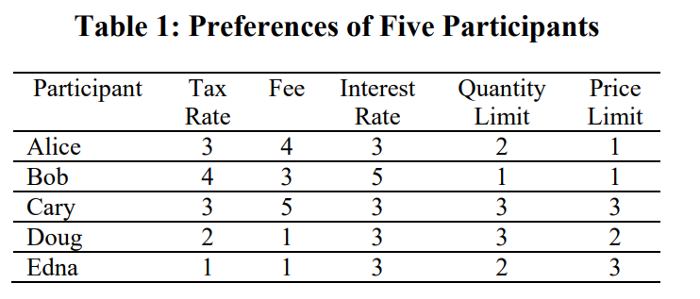

**Matriz de similitud (c)**

Salvo las de la diagonal, cada celda de la matriz de similitud se calcula negando la suma de los cuadrados de las diferencias entre los participantes.

Si eso no tiene ningún sentido para usted, no se preocupe, quedará claro una vez que vea un ejemplo. Para la similitud entre Alice y Bob, la suma de los cuadrados de las diferencias es (3–4)² + (4–3)² + (3–5)² + (2–1)² + (1–1) ² = 7.

Por lo tanto, el valor de similitud es -7.

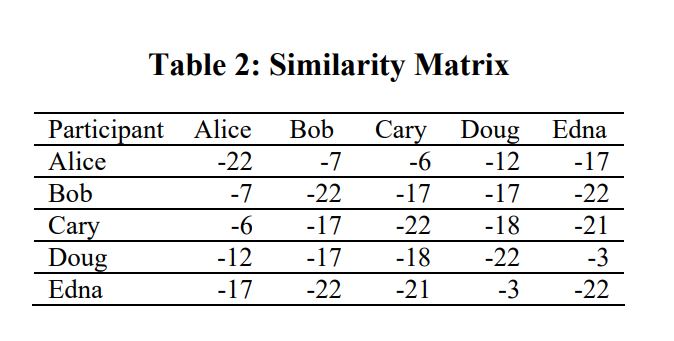

**Matriz de Responsabilidad (r)**

Comenzamos construyendo una matriz de disponibilidad con todos los elementos establecidos en cero. Luego, calculamos cada celda en la matriz de responsabilidad usando la siguiente fórmula:

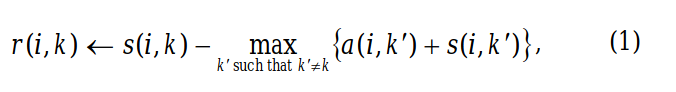

donde i se refiere a la fila yk a la columna de la matriz asociada.

Por ejemplo, la responsabilidad de Bob (columna) con Alice (fila) es -1, que es la similitud de Bob con Alice (-7) menos el máximo de las similitudes restantes de la fila de Alice (-6).

Después de calcular las responsabilidades para el resto de los pares de participantes, terminamos con la siguiente matriz

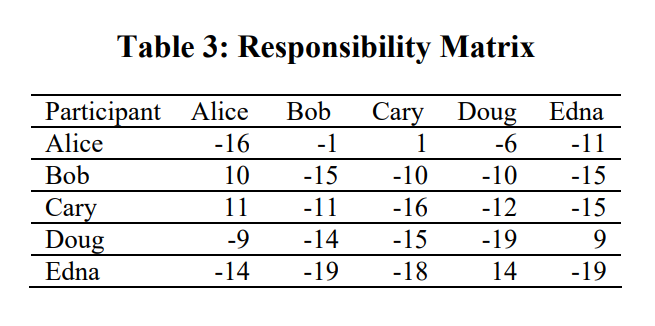

**Matriz de disponibilidad (a)**

Usamos una ecuación separada para actualizar los elementos en la diagonal de la matriz de disponibilidad que para los elementos fuera de la diagonal de la matriz de disponibilidad.

La fórmula anterior se utiliza para completar los elementos en la diagonal:

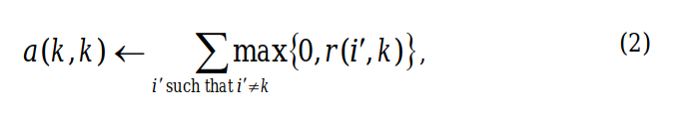

donde i se refiere a la fila yk a la columna de la matriz asociada.

En esencia, la ecuación te dice que sumes todos los valores por encima de 0 a lo largo de la columna excepto la fila cuyo valor es igual a la columna en cuestión. Por ejemplo, la autodisponibilidad de Alicia es la suma de las responsabilidades positivas de la columna de Alicia excluyendo la autorresponsabilidad de Alicia (10 + 11 + 0 + 0 = 21).

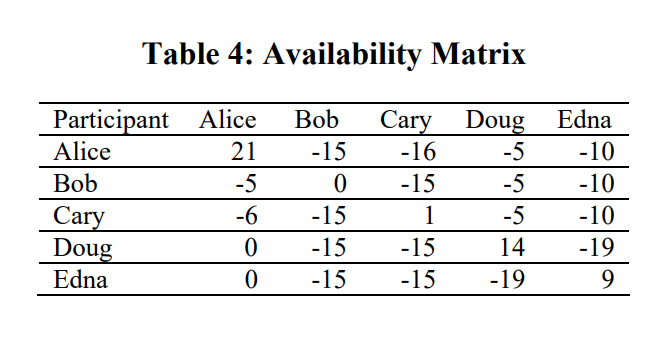

El usuario debe especificar dos parámetros:

1.	Preferencia que es un número negativo y controla cuántas copias se utilizan
2.	Factor de amortiguación que evita oscilaciones numéricas al actualizar los mensajes


In [ ]:
from sklearn.cluster import AffinityPropagation

### **Automatización**

In [ ]:
from sklearn.cluster import AffinityPropagation
from sklearn.metrics import silhouette_score
import numpy as np

def evaluar_affinitypropagation(data, pref_min=-20000, pref_max=-5000, pref_step=100, damping=0.9, random_state=42):
    mejor_score = -1
    mejor_pref = None
    mejor_modelo = None
    mejor_labels = None

    preferencias = np.arange(pref_min, pref_max + pref_step, pref_step)

    resultados = []

    for p in preferencias:
        try:
            modelo = AffinityPropagation(preference=p, damping=damping, random_state=random_state)
            labels = modelo.fit_predict(data)
            n_clusters = len(set(labels))
            if n_clusters > 1 and -1 not in set(labels):
                score = silhouette_score(data, labels)
                resultados.append({'preference': p, 'silhouette': score, 'n_clusters': n_clusters})
                if score > mejor_score:
                    mejor_score = score
                    mejor_pref = p
                    mejor_modelo = modelo
                    mejor_labels = labels
        except Exception as e:
            print(f"Preference {p} falló: {e}")
            continue

    resultados_df = pd.DataFrame(resultados)

    return resultados_df, mejor_modelo, mejor_pref, mejor_score, mejor_labels


In [ ]:
resultados_affinity, modelo_optimo, mejor_pref, mejor_score, etiquetas_optimas = evaluar_affinitypropagation(X_numerics)

if modelo_optimo is None:
    print("No se encontró ningún 'preference' que forme al menos 2 clusters.")
else:
    print(f"Mejor preference = {mejor_pref}, Silhouette Score = {mejor_score:.2f}, N clusters = {len(set(etiquetas_optimas))}")
    pipeline_affinity = Pipeline([
        ('spectral', AffinityPropagation(
            preference=mejor_pref, damping=0.9, random_state=42
        ))
    ])
    pipeline_affinity.fit(X_numerics)

Mejor preference = -14000, Silhouette Score = 0.45, N clusters = 6


In [ ]:
AF_clustered = X_numerics.copy()
AF_clustered['Cluster'] = etiquetas_optimas

In [ ]:
X_categoricas =  mall_data[['CustomerID', 'Gender']]

datos_final = pd.concat([X_categoricas,AF_clustered],axis = 1)

datos_final

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,1
1,2,Male,21,15,81,0
2,3,Female,20,16,6,1
3,4,Female,23,16,77,0
4,5,Female,31,17,40,1
...,...,...,...,...,...,...
195,196,Female,35,120,79,5
196,197,Female,45,126,28,4
197,198,Male,32,126,74,5
198,199,Male,32,137,18,4


In [ ]:
AF_clust_sizes = AF_clustered.groupby('Cluster').size().to_frame()
AF_clust_sizes.columns = ["AF_size"]
AF_clust_sizes

,AF_size
Cluster,
0,23
1,22
2,44
3,37
4,35
5,39


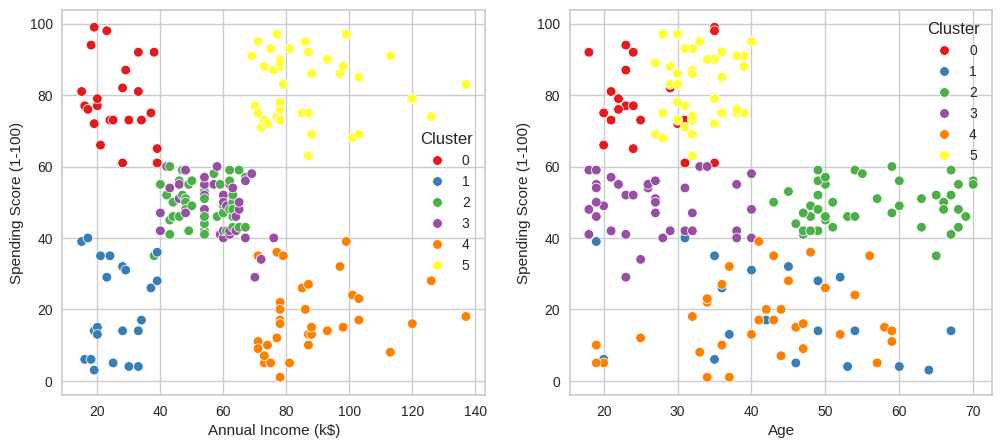

In [ ]:
# Crear los subplots
fig3, ax_af = plt.subplots(1, 2, figsize=(12, 5))

# Graficar el primer scatter plot
scat_1 = sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    data=AF_clustered,
    hue='Cluster',
    palette='Set1',
    ax=ax_af[0],
    legend='full'
)

# Graficar el segundo scatter plot
sns.scatterplot(
    x='Age',
    y='Spending Score (1-100)',
    data=AF_clustered,
    hue='Cluster',
    palette='Set1',
    ax=ax_af[1],
    legend='full'
)

# Ajustar las leyendas y el formato de texto
plt.setp(ax_af[0].get_legend().get_texts(), fontsize='10')
plt.setp(ax_af[1].get_legend().get_texts(), fontsize='10')

# Mostrar los gráficos
plt.show()



Los clústeres generados por el algoritmo Affinity Propagation crearon clústeres de tamaño relativamente uniforme similares a los creados por K-Means.

### **Spectral Clustering**

El Spectral Clustering es un método de agrupación en clústeres que utiliza técnicas de álgebra lineal y teoría espectral de grafos para realizar la agrupación de datos. A diferencia de los métodos tradicionales como K-Means, que asumen formas esféricas de los clústeres, Spectral Clustering puede capturar estructuras más complejas y no lineales en los datos.



**Conceptos Básicos**

El algoritmo se basa en la construcción de un grafo donde cada nodo representa un punto de datos, y las aristas conectan puntos similares. La similitud entre puntos se puede definir de diversas formas, pero comúnmente se utiliza una función de similitud basada en la distancia.

**Spectral Clustering frente a K-means**
* Compacidad: los puntos que se encuentran cerca unos de otros caen en el mismo agrupamiento y son compactos alrededor del centro del agrupamiento. La proximidad se puede medir por la distancia entre las observaciones. Por ejemplo: agrupamiento K-Means
* Conectividad: los puntos que están conectados o inmediatamente uno al lado del otro se colocan en el mismo agrupamiento. Incluso si la distancia entre 2 puntos es menor, si no están conectados, no se agrupan juntos. El agrupamiento espectral es una técnica que sigue este enfoque.

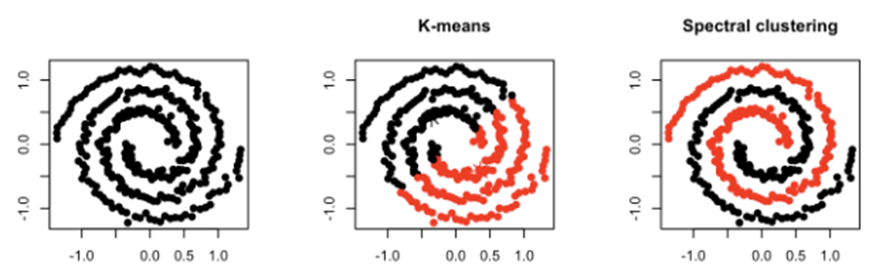

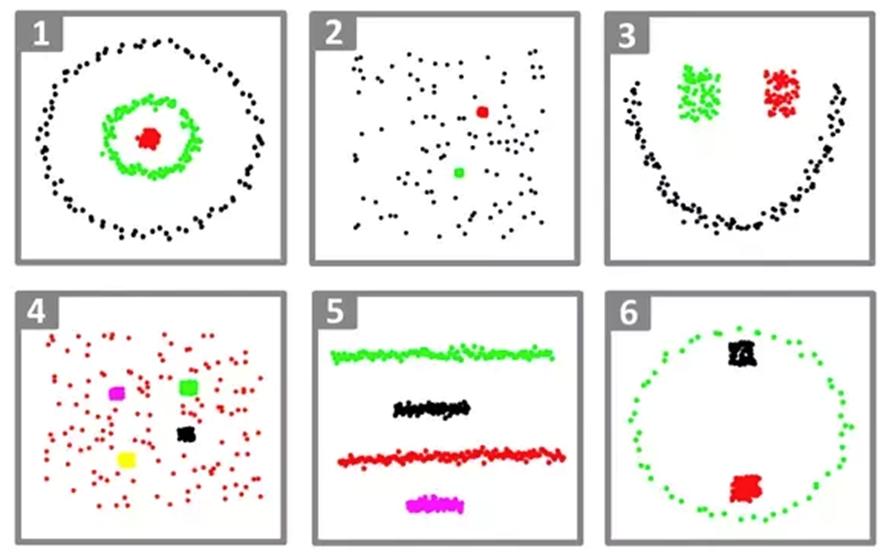

K-means no podrá agruparlos de manera efectiva, incluso cuando el algoritmo conozca el número real de grupos K. K-means, como algoritmo de agrupamiento de datos, es ideal para descubrir cúmulos globulares donde todos los miembros de cada grupo están muy cerca unos de otros (en sentido euclidiano).

El agrupamiento espectral es más general (y poderoso) porque si solo usamos la distancia euclidiana en su matriz de similitud, se comportará como k-means. Sin embargo, lo inverso no es cierto.

Si tenemos 𝑃 puntos de datos cada uno con 𝑁 dimensiones/características, la matriz de entrada para K-means sería 𝑁 por 𝑃, mientras que la matriz de entrada para el agrupamiento espectral sería 𝑃 por 𝑃.

El Spectral Clustering es indiferente al número de características que usemos (el núcleo gaussiano, que puede considerarse como una transformación de características de dimensión infinita, es particularmente popular cuando se usa el Spectral Clustering).

Tendremos dificultades para aplicar la agrupación espectral (al menos la versión básica) a conjuntos de datos muy grandes (gran 𝑃).

### **Pasos del Algoritmo**

1. **Construcción de la Matriz de Similitud (𝑊)**

Calculamos una matriz de similitud 𝑊 donde cada elemento 𝑊𝑖𝑗 representa la similitud entre los puntos 𝑖 y 𝑗.

Una función común para calcular 𝑊𝑖𝑗 es la Función Gaussiana:

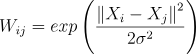

Donde:
* X𝑖 y X𝑗 son los vectores de características de los puntos
* ||X𝑖 - X𝑗 ||^2  es la distancia euclidiana al cuadrado entre los puntos 𝑖 y 𝑗.
* 𝜎 es un parámetro que controla el ancho de la vecindad y, por lo tanto, la similitud entre puntos.

2. **Construcción de la Matriz Laplaciana (𝐿)**

Primero, calculamos el grado de cada nodo, que es la suma de las similitudes de un nodo con todos los demás:

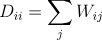

Donde:

* 𝐷 es una matriz diagonal donde cada elemento 𝐷𝑖𝑖 representa el grado del nodo 𝑖.

La matriz Laplaciana no normalizada se define entonces como: 𝐿=𝐷−𝑊


3. **Cálculo de los Vectores Propios:**

* Calculamos los 𝑘 primeros vectores propios (eigenvectores) de la matriz Laplaciana 𝐿.

* Estos vectores propios forman una representación de los datos en un espacio de menor dimensión.

4. **Agrupación en el Espacio de Vectores Propios:**

* Formamos una matriz 𝑈 con los 𝑘 vectores propios como columnas.

* Normalizamos las filas de 𝑈 para obtener la matriz 𝑇.

* Aplicamos un algoritmo de agrupación estándar (como K-Means) sobre las filas de 𝑇.

**Tipos de Matrices Laplacianas**

Existen diferentes variantes de la matriz Laplaciana que pueden usarse:

* Laplaciano No Normalizado:

𝐿=𝐷-𝑊

* Laplaciano Normalizado Simétrico:

image.png

* Laplaciano Normalizado Asimétrico:

image.png

**Parámetros Clave**

* Número de Clústeres (𝑘):
1. Debe especificarse el número de clústeres que se desean encontrar.
2. Puede determinarse mediante técnicas como el análisis del valor propio o métodos como el codo.
* Función de Similitud y Parámetros Asociados:
1. La elección de la función de similitud y sus parámetros (como 𝜎 en la función Gaussiana) afecta significativamente el resultado.
* Número de Vecinos (𝑛neighbors):
1. Al construir el grafo, puede ser útil conectar cada punto solo con sus vecinos más cercanos.

In [ ]:
from sklearn.cluster import SpectralClustering

In [ ]:
def evaluar_spectralclustering(data, n_min=2, n_max=10, affinity='nearest_neighbors', n_neighbors=10, random_state=42):
    mejor_score = -1
    mejor_n = None
    mejor_labels = None
    resultados = []

    for n_clusters in range(n_min, n_max + 1):
        try:
            modelo = SpectralClustering(
                n_clusters=n_clusters,
                assign_labels='kmeans',
                affinity=affinity,
                n_neighbors=n_neighbors,
                random_state=random_state
            )
            labels = modelo.fit_predict(data)
            n_clusters_real = len(set(labels))
            if n_clusters_real > 1:
                score = silhouette_score(data, labels)
                resultados.append({'n_clusters': n_clusters, 'silhouette': score, 'n_clusters_real': n_clusters_real})
                if score > mejor_score:
                    mejor_score = score
                    mejor_n = n_clusters
                    mejor_labels = labels
        except Exception as e:
            # Puedes imprimir el error si quieres depurar
            # print(f"Error en n_clusters={n_clusters}: {e}")
            continue

    resultados_df = pd.DataFrame(resultados)

    return resultados_df, mejor_n, mejor_score, mejor_labels


In [ ]:
resultados_spectral, mejor_n, mejor_score, etiquetas_optimas = evaluar_spectralclustering(X_numerics)

if mejor_n is None:
    print("No se encontró un número óptimo de clusters para SpectralClustering.")
else:
    print(f"Mejor número de clusters: {mejor_n}, Silhouette Score: {mejor_score:.2f}, N clusters reales: {len(set(etiquetas_optimas))}")

    pipeline_spectral = Pipeline([
        ('spectral', SpectralClustering(
            n_clusters=mejor_n,
            assign_labels='kmeans',
            affinity='nearest_neighbors',
            n_neighbors=10,
            random_state=42
        ))
    ])
    pipeline_spectral.fit(X_numerics)

Mejor número de clusters: 6, Silhouette Score: 0.45, N clusters reales: 6


In [ ]:
# Crear DataFrame con resultados
Spectral_clustered = X_numerics.copy()
Spectral_clustered['Cluster'] = etiquetas_optimas

In [ ]:
# Tamaños de clústeres
Spectral_cluster_sizes = Spectral_clustered['Cluster'].value_counts().to_frame()
Spectral_cluster_sizes.columns = ['Spectral_size']

Spectral_cluster_sizes

,Spectral_size
Cluster,
2,51
1,39
0,34
4,33
5,22
3,21


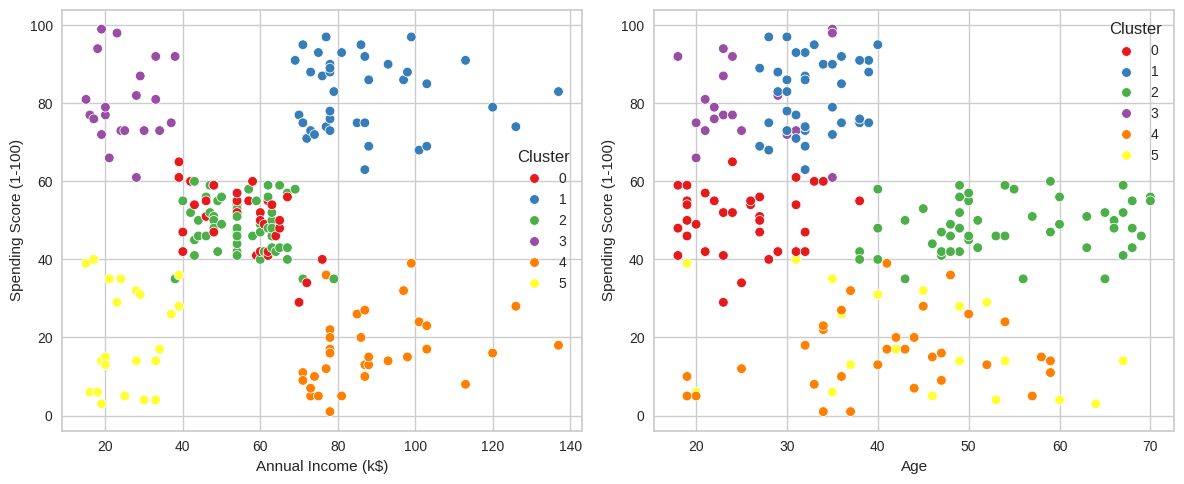

In [ ]:
# Crear los subplots
fig4, ax_spectral = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico 1: Ingreso Anual vs Puntuación de Gasto
sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    data=Spectral_clustered,
    hue='Cluster',
    palette='Set1',
    ax=ax_spectral[0],
    legend='full'
)

# Gráfico 2: Edad vs Puntuación de Gasto
sns.scatterplot(
    x='Age',
    y='Spending Score (1-100)',
    data=Spectral_clustered,
    hue='Cluster',
    palette='Set1',
    ax=ax_spectral[1],
    legend='full'
)

# Ajustar las leyendas y el formato de texto
plt.setp(ax_spectral[0].get_legend().get_texts(), fontsize='10')
plt.setp(ax_spectral[1].get_legend().get_texts(), fontsize='10')

# Mostrar los gráficos
plt.tight_layout()
plt.show()


### Comparación y discusión

En esta sesion se compararán y discutirán los clústeres generados por 3 algoritmos investigados.

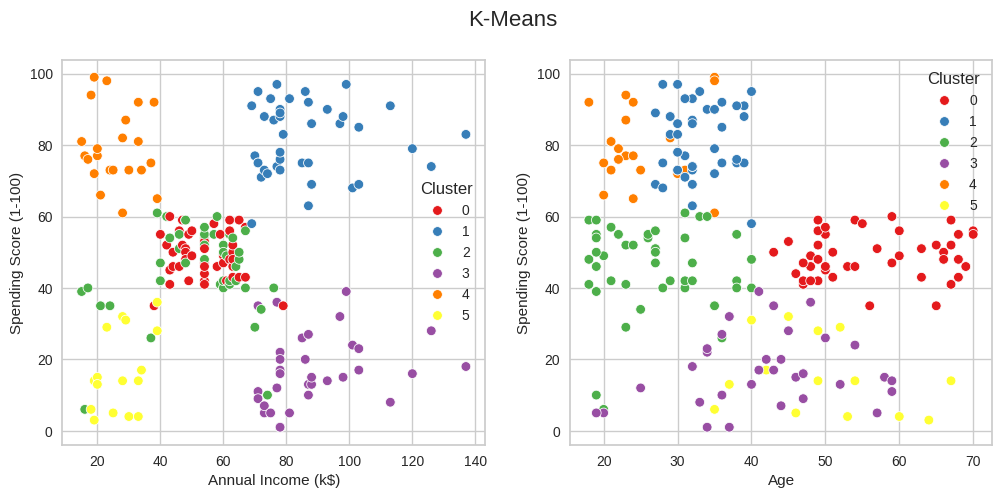

In [ ]:
fig1.suptitle('K-Means', fontsize=16)
fig1

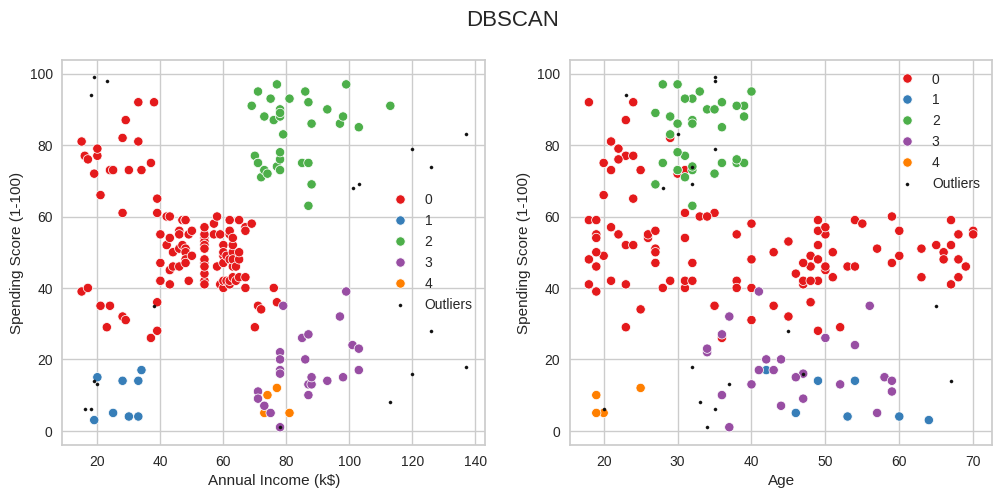

In [ ]:
fig2.suptitle('DBSCAN', fontsize=16)
fig2

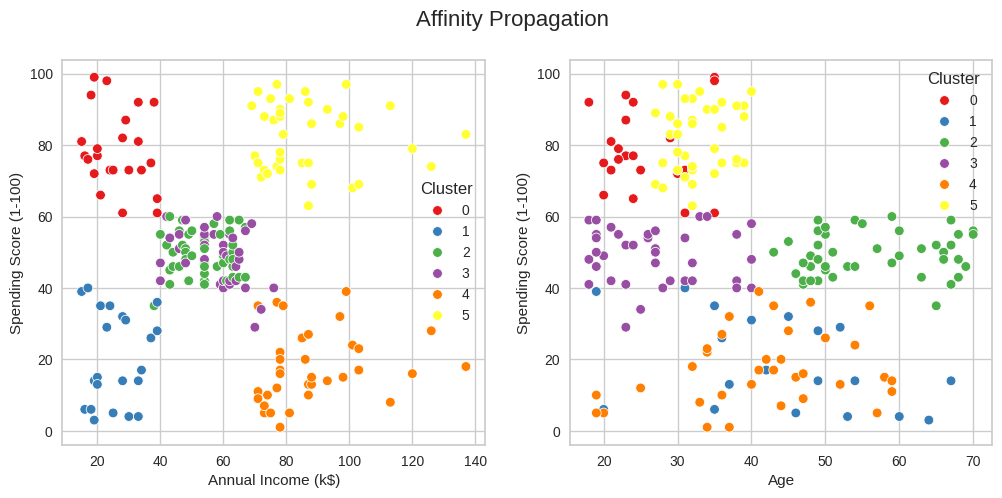

In [ ]:
fig3.suptitle('Affinity Propagation', fontsize=16)
fig3

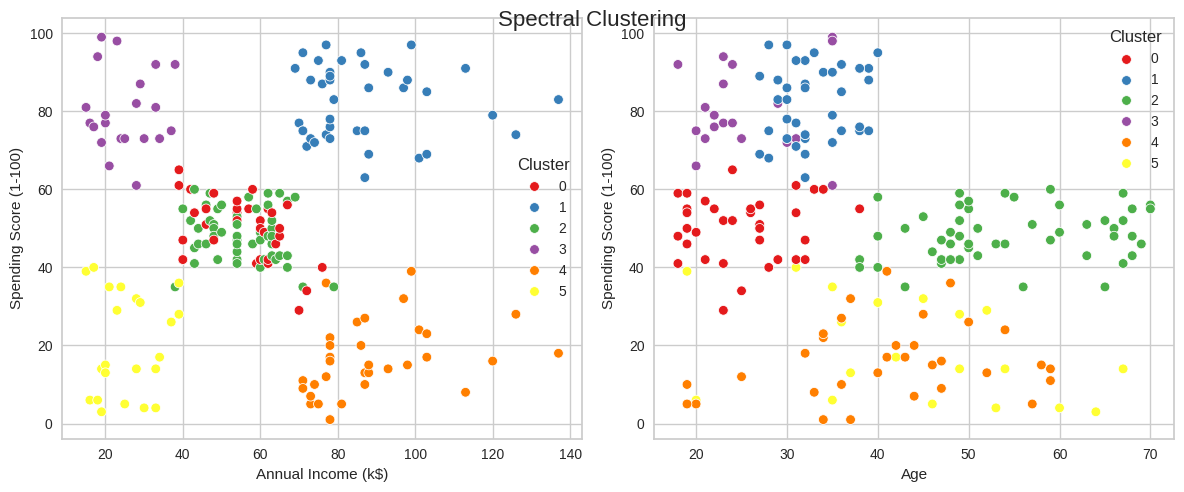

In [ ]:
fig4.suptitle('Spectral Clustering', fontsize=16)
fig4

La siguiente tabla muestra los tamaños de los clústeres creados. Tenga en cuenta que la numeración de los grupos es diferente en cada método, p. el clúster n.º 0 en K-Means es equivalente al clúster n.º 2 en DBSCAN y al n.º 2 en Affinity Propagation.

In [ ]:
clusters = pd.concat([KM_clust_sizes, DBSCAN_clust_sizes, AF_clust_sizes,Spectral_cluster_sizes],axis=1, sort=False)
clusters

,Tamanio_KMeans,DBSCAN_size,AF_size,Spectral_size
Cluster,,,,
0,45.0,112.0,23.0,34.0
1,40.0,8.0,22.0,39.0
2,44.0,34.0,44.0,51.0
3,33.0,24.0,37.0,21.0
4,22.0,4.0,35.0,33.0
5,16.0,NaN,39.0,22.0
-1,NaN,18.0,NaN,NaN


De las comparaciones anteriores, está claro que DBSCAN no pudo generar clústeres razonables. Lo más probable es que DBCSAN intente encontrar grupos basados en la densidad de puntos. Si uno de nuestros clústeres es menos denso que otros, DBSCAN producirá resultados subóptimos al no reconocer el grupo menos denso como un clúster.
A su vez, los algoritmos K-Means y Affinity Propagation crearon 6 clústeres razonables.
